In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from datetime import datetime
import os

def load_idx_images(filepath):
    import struct
    with open(filepath, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
    return images

def load_idx_labels(filepath):
    import struct
    with open(filepath, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

def prepare_data(images, labels, num_classes=62):
    X = images.astype('float32') / 255.0
    X = np.expand_dims(X, axis=-1)

    y = keras.utils.to_categorical(labels, num_classes)

    return X, y

def create_simple_model(num_classes=62, input_shape=(28, 28, 1)):
    model = keras.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Conv Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Fully Connected
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def create_model(num_classes=62, input_shape=(28, 28, 1)):
    model = keras.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Conv Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Conv Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Fully Connected
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

def get_callbacks(model_name, initial_lr=0.001):
    checkpoint = keras.callbacks.ModelCheckpoint(
        f'{model_name}_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )

    def lr_schedule(epoch):
        if epoch < 15:
            return initial_lr
        elif epoch < 30:
            return initial_lr * 0.5
        elif epoch < 45:
            return initial_lr * 0.1
        else:
            return initial_lr * 0.01

    lr_scheduler = keras.callbacks.LearningRateScheduler(lr_schedule, verbose=1)

    return [checkpoint, early_stop, reduce_lr, lr_scheduler]

def plot_history(history, dataset_name):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{dataset_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{dataset_name} - Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{dataset_name}_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

from sklearn.metrics import f1_score, classification_report
import numpy as np
from datetime import datetime

def evaluate_model(model, X_test, y_test, dataset_name, save_report=True):
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    y_prob = model.predict(X_test, batch_size=256, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{'='*70}")
    print(f"{dataset_name} - FINAL EVALUATION")
    print(f"{'='*70}")
    print(f"Test Loss      : {test_loss:.4f}")
    print(f"Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"F1-score Macro : {f1_macro:.4f}")
    print(f"F1-score Weight: {f1_weighted:.4f}")
    print(f"{'='*70}\n")

    with open("training_results.txt", "a") as f:
        f.write(f"{dataset_name} - Results\n")
        f.write(f"Test Loss      : {test_loss:.4f}\n")
        f.write(f"Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)\n")
        f.write(f"F1-score Macro : {f1_macro:.4f}\n")
        f.write(f"F1-score Weight: {f1_weighted:.4f}\n")
        f.write(f"Timestamp      : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

    if save_report:
        report = classification_report(y_true, y_pred, digits=4)
        print(report)
        with open(f"{dataset_name}_classification_report.txt", "w") as f:
            f.write(report)

    return {
        "loss": test_loss,
        "accuracy": test_acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }


In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

upload_dir = "/content/drive/MyDrive/data"

os.makedirs(upload_dir, exist_ok=True)

print("Upload directory ready:", upload_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Upload directory ready: /content/drive/MyDrive/data


In [ ]:
from google.colab import drive
import zipfile, os, shutil

drive.mount('/content/drive')

zips = {
    "original":  "/content/drive/MyDrive/data/original.zip",
    "noisy":     "/content/drive/MyDrive/data/noisy.zip",
    "balanced":  "/content/drive/MyDrive/data/balanced.zip",
}

base_dir = "/content/data"
os.makedirs(base_dir, exist_ok=True)

for name, zip_path in zips.items():
    print(f"\nExtracting {name}.zip")

    tmp = f"/content/tmp"
    out = f"{base_dir}/{name}"

    if os.path.exists(tmp):
        shutil.rmtree(tmp)
    os.makedirs(tmp)

    with zipfile.ZipFile(zip_path) as z:
        z.extractall(tmp)

    files = os.listdir(tmp)
    src = os.path.join(tmp, files[0]) if len(files) == 1 else tmp

    if os.path.exists(out):
        shutil.rmtree(out)
    shutil.move(src, out)

    shutil.rmtree(tmp)
    print(f"Done -> {out}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Extracting original.zip
Done -> /content/data/original

Extracting noisy.zip
Done -> /content/data/noisy

Extracting balanced.zip
Done -> /content/data/balanced


TRAINING ON ORIGINAL DATASET - SIMPLE MODEL
Train: 697932 images
Test: 116323 images



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428,350 (1.63 MB)

 Trainable params: 428,350 (1.63 MB)

 Non-trainable params: 0 (0.00 B)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/50
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6711 - loss: 1.1697
Epoch 1: val_accuracy improved from -inf to 0.84017, saving model to emnist_original_simple_model_best.keras
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 36s 6ms/step - accuracy: 0.6711 - loss: 1.1697 - val_accuracy: 0.8402 - val_loss: 0.4500 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/50
4898/4908 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8003 - loss: 0.6062
Epoch 2: val_accuracy improved from 0.84017 to 0.84911, saving model to emnist_original_simple_model_best.keras
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.8003 - loss: 0.6062 - val_accuracy: 0.8491 - val_loss: 0.4192 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/50
4900/4908 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8152 - loss: 0.5550
Epoch 3: val_accuracy improved from

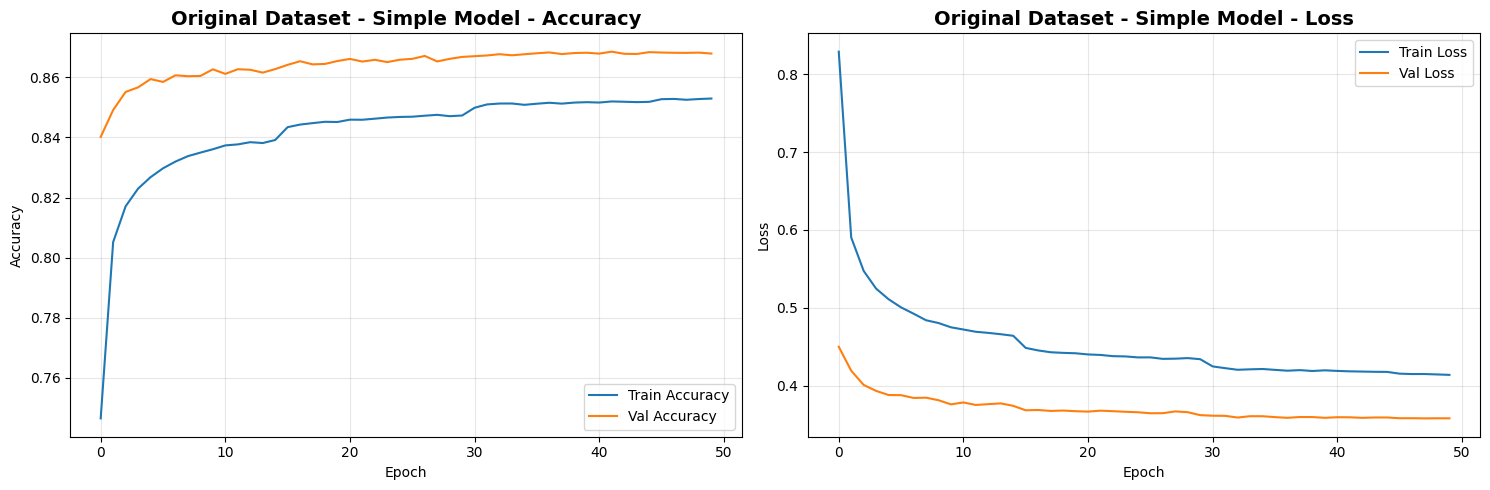


ORIGINAL DATASET - SIMPLE MODEL - FINAL EVALUATION
Test Loss      : 0.3548
Test Accuracy  : 0.8688 (86.88%)
F1-score Macro : 0.7294
F1-score Weight: 0.8504

              precision    recall  f1-score   support

           0     0.6921    0.8060    0.7447      5778
           1     0.6677    0.9482    0.7836      6330
           2     0.9519    0.9836    0.9675      5869
           3     0.9938    0.9933    0.9935      5969
           4     0.9621    0.9797    0.9708      5619
           5     0.9666    0.9210    0.9433      5190
           6     0.9665    0.9863    0.9763      5705
           7     0.9868    0.9950    0.9908      6139
           8     0.9737    0.9870    0.9803      5633
           9     0.9180    0.9859    0.9507      5686
          10     0.9445    0.9783    0.9611      1062
          11     0.9492    0.9522    0.9507       648
          12     0.7724    0.9661    0.8585      1739
          13     0.9208    0.8652    0.8921       779
          14     0.9623    0.95

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [2]:
print("TRAINING ON ORIGINAL DATASET - SIMPLE MODEL")

# Load data
def rotate(images):
    images = np.array([np.rot90(np.fliplr(img)) for img in images])
    return images

train_images = load_idx_images('data/original/emnist-byclass-train-images-idx3-ubyte')
train_labels = load_idx_labels('data/original/emnist-byclass-train-labels-idx1-ubyte')
test_images = load_idx_images('data/original/emnist-byclass-test-images-idx3-ubyte')
test_labels = load_idx_labels('data/original/emnist-byclass-test-labels-idx1-ubyte')

train_images = rotate(train_images)
test_images = rotate(test_images)

print(f"Train: {len(train_images)} images")
print(f"Test: {len(test_images)} images\n")

# Prepare data
X_train, y_train = prepare_data(train_images, train_labels, num_classes=62)
X_test, y_test   = prepare_data(test_images, test_labels, num_classes=62)

# Create and compile simple model
simple_model_original = create_simple_model()
simple_model_original.summary()

initial_lr = 0.001
optimizer = keras.optimizers.Adam(learning_rate=initial_lr)
simple_model_original.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_simple_original = simple_model_original.fit(
    X_train, y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.1,
    callbacks=get_callbacks('emnist_original_simple_model'),
    verbose=1
)

# Plot history
plot_history(history_simple_original, 'Original Dataset - Simple Model')

# Evaluate
results_simple_orig = evaluate_model(
    simple_model_original,
    X_test,
    y_test,
    'ORIGINAL DATASET - SIMPLE MODEL'
)

test_loss_simple_orig = results_simple_orig["loss"]
test_acc_simple_orig  = results_simple_orig["accuracy"]
f1_macro_simple_orig  = results_simple_orig["f1_macro"]
f1_weighted_simple_orig = results_simple_orig["f1_weighted"]

# Save model
os.makedirs('models', exist_ok=True)
simple_model_original.save('models/emnist_original_simple.keras')


TRAINING ON ORIGINAL DATASET
Train: 697932 images
Test: 116323 images



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,028,894 (3.92 MB)

 Trainable params: 1,026,462 (3.92 MB)

 Non-trainable params: 2,432 (9.50 KB)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/50
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7353 - loss: 0.9101
Epoch 1: val_accuracy improved from -inf to 0.85353, saving model to emnist_original_model_best.keras
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 92s 15ms/step - accuracy: 0.7354 - loss: 0.9100 - val_accuracy: 0.8535 - val_loss: 0.3942 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/50
4906/4908 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8458 - loss: 0.4344
Epoch 2: val_accuracy improved from 0.85353 to 0.86357, saving model to emnist_original_model_best.keras
4908/4908 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - accuracy: 0.8458 - loss: 0.4344 - val_accuracy: 0.8636 - val_loss: 0.3699 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/50
4905/4908 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8555 - loss: 0.4000
Epoch 3: val_accuracy improved from 0.86357 

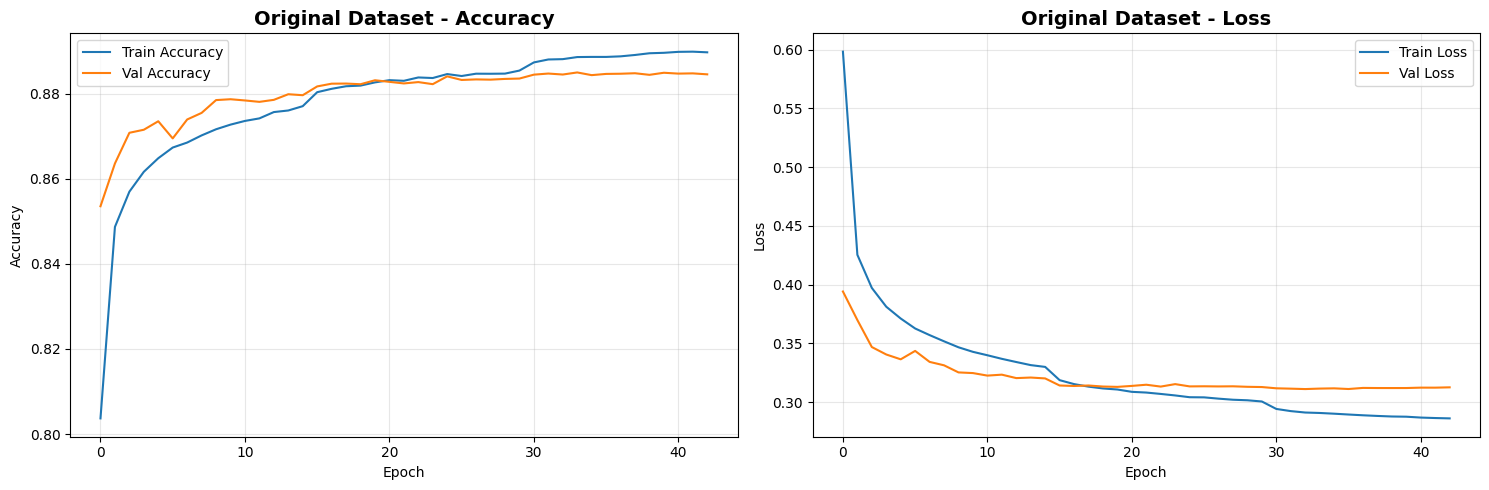


ORIGINAL DATASET - FINAL RESULTS
Test Loss: 0.3109
Test Accuracy: 0.8840 (88.40%)



In [ ]:
print("TRAINING ON ORIGINAL DATASET")

# Load data
def rotate(images):
    images = np.array([np.rot90(np.fliplr(img)) for img in images])
    return images

train_images = load_idx_images('data/original/emnist-byclass-train-images-idx3-ubyte')
train_labels = load_idx_labels('data/original/emnist-byclass-train-labels-idx1-ubyte')
test_images = load_idx_images('data/original/emnist-byclass-test-images-idx3-ubyte')
test_labels = load_idx_labels('data/original/emnist-byclass-test-labels-idx1-ubyte')

train_images = rotate(train_images)
test_images = rotate(test_images)

print(f"Train: {len(train_images)} images")
print(f"Test: {len(test_images)} images\n")

# Prepare data
X_train, y_train = prepare_data(train_images, train_labels, num_classes=62)
X_test, y_test   = prepare_data(test_images, test_labels, num_classes=62)

# Create and compile model
model_original = create_model()
model_original.summary()

initial_lr = 0.001
optimizer = keras.optimizers.Adam(learning_rate=initial_lr)
model_original.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_original = model_original.fit(
    X_train, y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.1,
    callbacks=get_callbacks('emnist_original_model'),
    verbose=1
)

# Plot history
plot_history(history_original, 'Original Dataset')

# Evaluate
results_orig = evaluate_model(
    simple_model_original,
    X_test,
    y_test,
    'ORIGINAL DATASET - STANDARD MODEL'
)

test_loss_orig = results_orig["loss"]
test_acc_orig  = results_orig["accuracy"]
f1_macro_orig  = results_orig["f1_macro"]
f1_weighted_orig = results_orig["f1_weighted"]

os.makedirs('models', exist_ok=True)
model_original.save('models/emnist_original.keras')

In [ ]:
print("TRAINING ON BALANCED DATASET - SIMPLE MODEL")

train_images = load_idx_images('data/balanced/emnist-byclass-train-images-idx3-ubyte')
train_labels = load_idx_labels('data/balanced/emnist-byclass-train-labels-idx1-ubyte')
test_images = load_idx_images('data/balanced/emnist-byclass-test-images-idx3-ubyte')
test_labels = load_idx_labels('data/balanced/emnist-byclass-test-labels-idx1-ubyte')

print(f"Train: {len(train_images)} images")
print(f"Test: {len(test_images)} images\n")

# Prepare data
X_train, y_train = prepare_data(train_images, train_labels, num_classes=62)
X_test, y_test   = prepare_data(test_images, test_labels, num_classes=62)

# Create and compile simple model
simple_model_balanced = create_simple_model()
simple_model_balanced.summary()

initial_lr = 0.001
optimizer = keras.optimizers.Adam(learning_rate=initial_lr)
simple_model_balanced.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_simple_balanced = simple_model_balanced.fit(
    X_train, y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.1,
    callbacks=get_callbacks('emnist_balanced_simple_model'),
    verbose=1
)

# Plot history
plot_history(history_simple_balanced, 'Balanced Dataset - Simple Model')

# Evaluate
results_simple_balanced = evaluate_model(
    simple_model_balanced,
    X_test,
    y_test,
    'BALANCED DATASET - SIMPLE MODEL'
)

test_loss_simple_balanced = results_simple_balanced["loss"]
test_acc_simple_balanced  = results_simple_balanced["accuracy"]
f1_macro_simple_balanced  = results_simple_balanced["f1_macro"]
f1_weighted_simple_balanced = results_simple_balanced["f1_weighted"]

# Save model
os.makedirs('models', exist_ok=True)
simple_model_original.save('models/emnist_balanced_simple.keras')


In [ ]:
print("TRAINING ON BALANCED DATASET")

# Load data
train_images = load_idx_images('data/balanced/emnist-byclass-train-images-idx3-ubyte')
train_labels = load_idx_labels('data/balanced/emnist-byclass-train-labels-idx1-ubyte')
test_images = load_idx_images('data/balanced/emnist-byclass-test-images-idx3-ubyte')
test_labels = load_idx_labels('data/balanced/emnist-byclass-test-labels-idx1-ubyte')

print(f"Train: {len(train_images)} images")
print(f"Test: {len(test_images)} images\n")

# Prepare data
X_train, y_train = prepare_data(train_images, train_labels, num_classes=62)
X_test, y_test   = prepare_data(test_images, test_labels, num_classes=62)

# Create and compile model
model_balanced = create_model()
model_balanced.summary()

optimizer = keras.optimizers.Adam(learning_rate=initial_lr)
model_balanced.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_balanced = model_balanced.fit(
    X_train, y_train,
    batch_size=128,
    epochs=60,
    validation_split=0.1,
    callbacks=get_callbacks('emnist_balanced_model'),
    verbose=1
)

# Plot history
plot_history(history_balanced, 'Balanced Dataset')

# Evaluate
results_balanced = evaluate_model(
    model_balanced,
    X_test,
    y_test,
    'BALANCED DATASET - STANDARD MODEL'
)

test_loss_balanced = results_balanced["loss"]
test_acc_balanced  = results_balanced["accuracy"]
f1_macro_balanced  = results_balanced["f1_macro"]
f1_weighted_balanced = results_balanced["f1_weighted"]

model_balanced.save('models/emnist_balanced.keras')

In [ ]:
print("TRAINING ON NOISY DATASET - SIMPLE MODEL")

train_images = load_idx_images('data/noisy/emnist-byclass-train-images-idx3-ubyte')
train_labels = load_idx_labels('data/noisy/emnist-byclass-train-labels-idx1-ubyte')
test_images = load_idx_images('data/noisy/emnist-byclass-test-images-idx3-ubyte')
test_labels = load_idx_labels('data/noisy/emnist-byclass-test-labels-idx1-ubyte')

print(f"Train: {len(train_images)} images")
print(f"Test: {len(test_images)} images\n")

# Prepare data
X_train, y_train = prepare_data(train_images, train_labels, num_classes=62)
X_test, y_test   = prepare_data(test_images, test_labels, num_classes=62)

# Create and compile simple model
simple_model_noisy = create_simple_model()
simple_model_noisy.summary()

initial_lr = 0.001
optimizer = keras.optimizers.Adam(learning_rate=initial_lr)
simple_model_noisy.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_simple_noisy = simple_model_noisy.fit(
    X_train, y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.1,
    callbacks=get_callbacks('emnist_noisy_simple_model'),
    verbose=1
)

# Plot history
plot_history(history_simple_noisy, 'Noisy Dataset - Simple Model')

# Evaluate
results_simple_noisy = evaluate_model(
    simple_model_noisy,
    X_test,
    y_test,
    'NOISY DATASET - SIMPLE MODEL'
)

test_loss_simple_noisy = results_simple_noisy["loss"]
test_acc_simple_noisy  = results_simple_noisy["accuracy"]
f1_macro_simple_noisy  = results_simple_noisy["f1_macro"]
f1_weighted_simple_noisy = results_simple_noisy["f1_weighted"]

# Save model
os.makedirs('models', exist_ok=True)
simple_model_noisy.save('models/emnist_noisy_simple.keras')


In [ ]:
print("TRAINING ON NOISY DATASET")

# Load data
train_images = load_idx_images('data/noisy/emnist-byclass-train-images-idx3-ubyte')
train_labels = load_idx_labels('data/noisy/emnist-byclass-train-labels-idx1-ubyte')
test_images = load_idx_images('data/noisy/emnist-byclass-test-images-idx3-ubyte')
test_labels = load_idx_labels('data/noisy/emnist-byclass-test-labels-idx1-ubyte')

print(f"Train: {len(train_images)} images")
print(f"Test: {len(test_images)} images\n")

# Prepare data
X_train, y_train = prepare_data(train_images, train_labels, num_classes=62)
X_test, y_test   = prepare_data(test_images, test_labels, num_classes=62)

# Create and compile model
model_noisy = create_model()
model_noisy.summary()

optimizer = keras.optimizers.Adam(learning_rate=initial_lr)
model_noisy.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_noisy = model_noisy.fit(
    X_train, y_train,
    batch_size=128,
    epochs=60,
    validation_split=0.1,
    callbacks=get_callbacks('emnist_noisy_model'),
    verbose=1
)

# Plot history
plot_history(history_noisy, 'Noisy Dataset')

# Evaluate
results_noisy = evaluate_model(
    model_noisy,
    X_test,
    y_test,
    'NOISY DATASET - STANDARD MODEL'
)

test_loss_noisy = results_noisy["loss"]
test_acc_noisy  = results_noisy["accuracy"]
f1_macro_noisy  = results_noisy["f1_macro"]
f1_weighted_noisy = results_noisy["f1_weighted"]

model_noisy.save('models/emnist_noisy.keras')